# Taller ingeniería de datos

El problema que se desea resolver haciendo un modelo predictivo es el siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Cargue el archivo de datos, y haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

In [24]:
import pandas as pd 
from pathlib import Path

DATA_DIR = Path().resolve().parent / "data" / "data talleres"
file_name = "Telco_customer_churn.csv"
file_path = DATA_DIR / file_name

df = pd.read_csv(file_path, na_values= ' ')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [26]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [27]:
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [28]:
df = df.drop(
    columns=[
        'Count', #Valor único
        'CustomerID', #Clave primaria
        'Country', #Valor único
        'State', #Valor único
        'Lat Long', #Redundante con Longitud y Latitud
        'Churn Value', #Misma variable objetivo
        'Churn Reason', #Filtración de datos
    ]
)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Zip Code           7043 non-null   int64  
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   object 
 5   Senior Citizen     7043 non-null   object 
 6   Partner            7043 non-null   object 
 7   Dependents         7043 non-null   object 
 8   Tenure Months      7043 non-null   int64  
 9   Phone Service      7043 non-null   object 
 10  Multiple Lines     7043 non-null   object 
 11  Internet Service   7043 non-null   object 
 12  Online Security    7043 non-null   object 
 13  Online Backup      7043 non-null   object 
 14  Device Protection  7043 non-null   object 
 15  Tech Support       7043 non-null   object 
 16  Streaming TV       7043 

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.

Reporte los resultados del análisis en una celda de texto.

In [30]:
cat_vars = df.select_dtypes(include='object').columns.to_list()

cat_vars

['City',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Churn Label']

**Variables nominales**
- City -> Alta cardinalidad 
- Gender (binaria)
- Senior Citizen
- Partner
- Dependents
- Phone service
- Multiple lines
- Internet service
- Online security
- Online backup
- Device protection
- Tech support
- Streaming TV
- Streaming movies
- Paperless billing
- Payment method
- Churn label


**Variables ordinales**
- Contract

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Reporte los resultados del análisis en una celda de texto.

array([[<Axes: title={'center': 'Zip Code'}>,
        <Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>],
       [<Axes: title={'center': 'Tenure Months'}>,
        <Axes: title={'center': 'Monthly Charges'}>,
        <Axes: title={'center': 'Total Charges'}>],
       [<Axes: title={'center': 'Churn Score'}>,
        <Axes: title={'center': 'CLTV'}>, <Axes: >]], dtype=object)

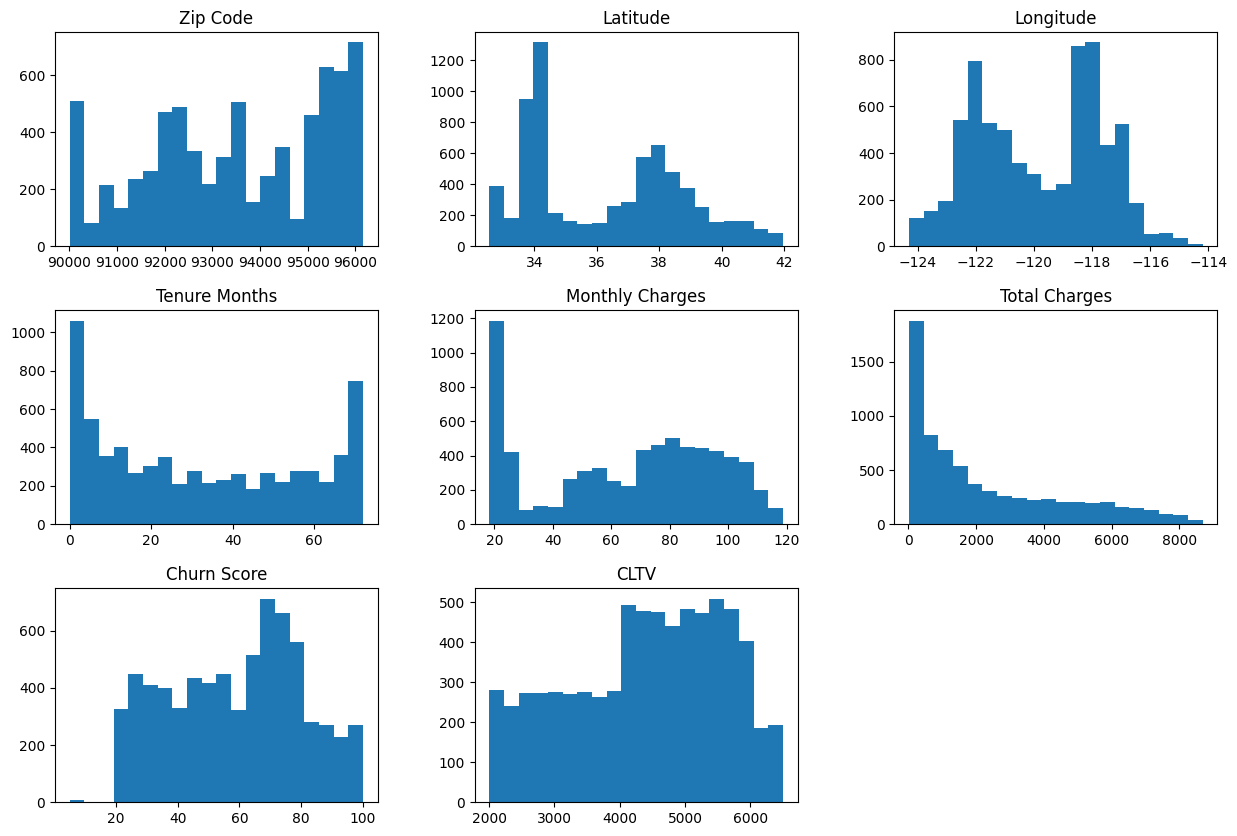

In [32]:
df.hist(
    bins=20,
    grid=False,
    figsize=(15,10)
)

**Bimodal** (dos picos):
- Latitude
- Longitude
- Ternure months
- Monthly charges

**Exponencial**
- Total charges

**NINGUNA NORMAL NO TIENEN FORMA DE CAMPANA**

Hacemos una prueba de bondad de ajuste para confirmar

In [33]:
from scipy.stats import kstest

num_vars = df.select_dtypes(include=["number"]).columns

for num in num_vars:
    __, p_value = kstest(df[num], 'norm', args=(df[num].mean(), df[num].std()))
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()

Prueba de Kolmogorov-Smirnov para Zip Code:
  Valor p: 4.349499185284863e-89
  Zip Code no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Latitude:
  Valor p: 7.384987152439983e-206
  Latitude no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Longitude:
  Valor p: 1.9882961763379662e-110
  Longitude no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Tenure Months:
  Valor p: 4.662721654217928e-76
  Tenure Months no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Monthly Charges:
  Valor p: 3.1510583248297797e-98
  Monthly Charges no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Total Charges:
  Valor p: nan
  Total Charges no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Churn Score:
  Valor p: 6.651675296607391e-37
  Churn Score no parece ser normal (se rechaza la hi

## Valores atípicos

Zip Code              Axes(0.125,0.653529;0.227941x0.226471)
Latitude           Axes(0.398529,0.653529;0.227941x0.226471)
Longitude          Axes(0.672059,0.653529;0.227941x0.226471)
Tenure Months         Axes(0.125,0.381765;0.227941x0.226471)
Monthly Charges    Axes(0.398529,0.381765;0.227941x0.226471)
Total Charges      Axes(0.672059,0.381765;0.227941x0.226471)
Churn Score               Axes(0.125,0.11;0.227941x0.226471)
CLTV                   Axes(0.398529,0.11;0.227941x0.226471)
dtype: object

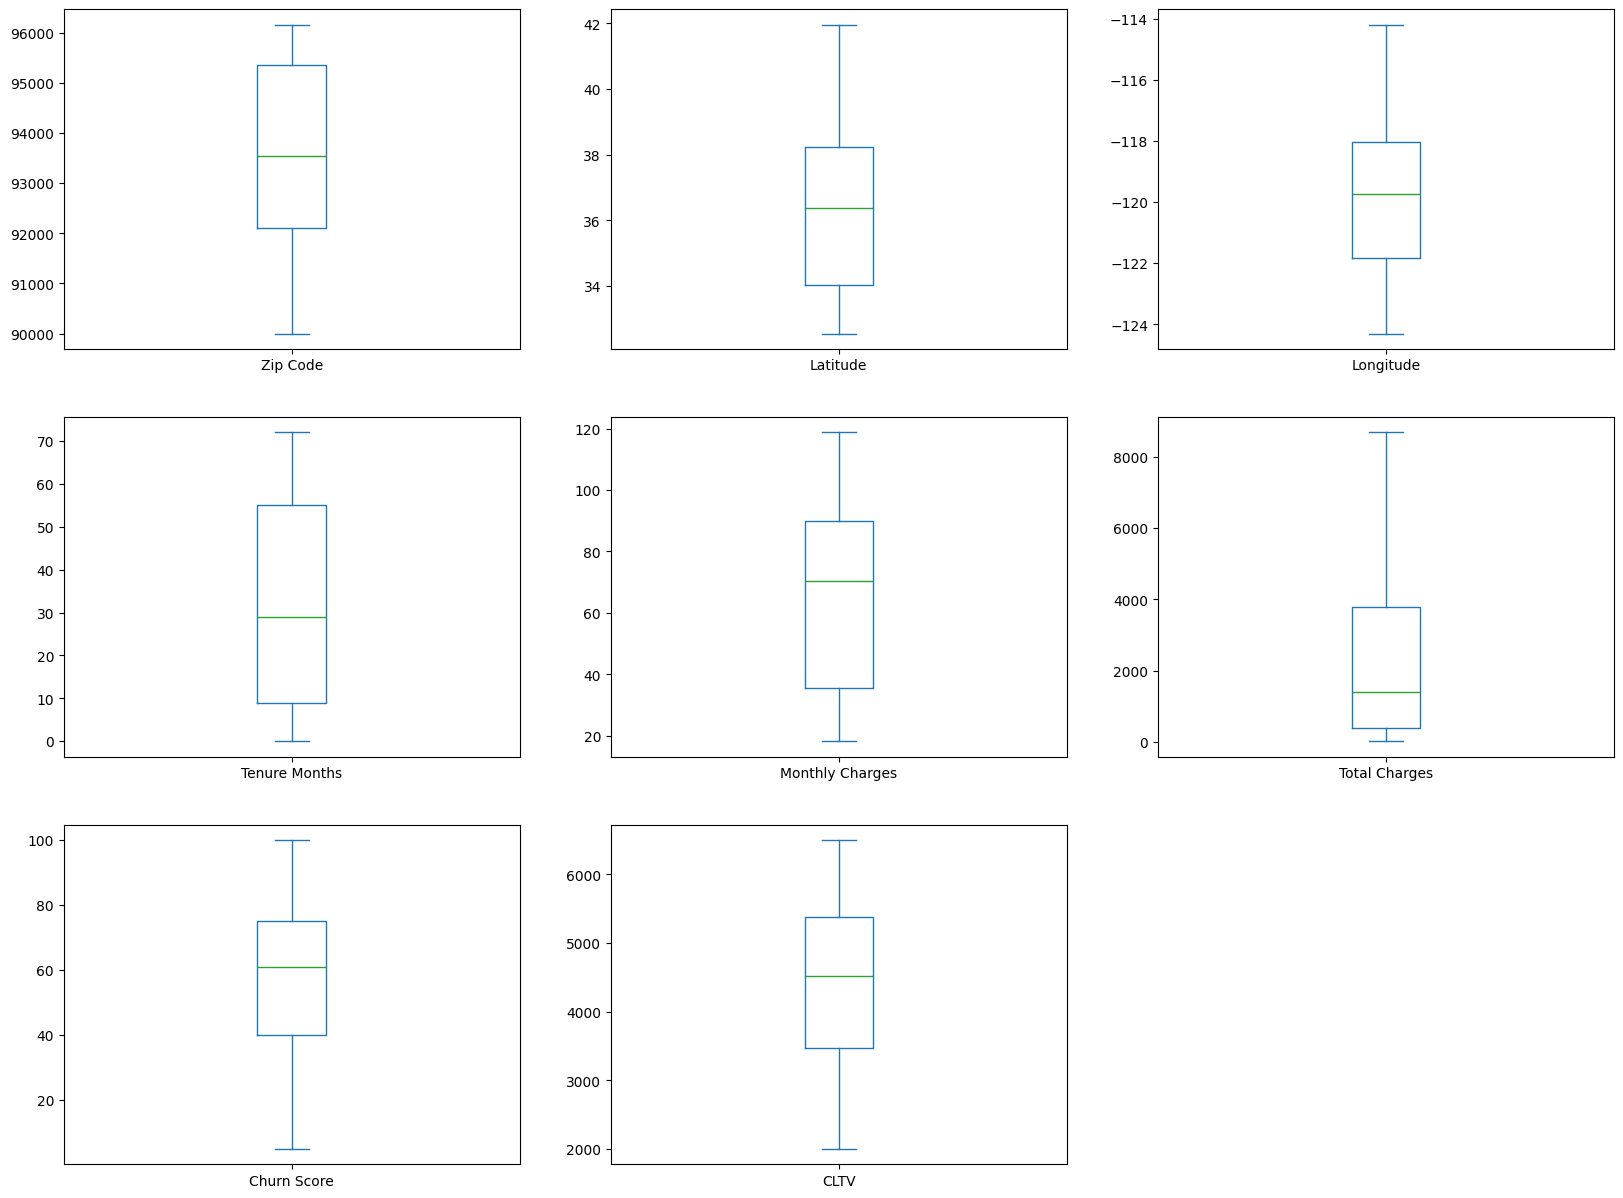

In [36]:
df.select_dtypes(include=['int64', 'float64']).plot(
    kind='box',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

**No hay valoers atípicos**

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Churn Label**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 6 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 6 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

<Figure size 1000x1000 with 0 Axes>

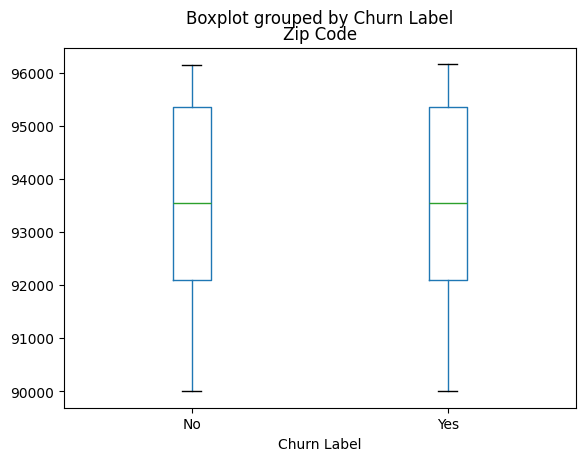

<Figure size 1000x1000 with 0 Axes>

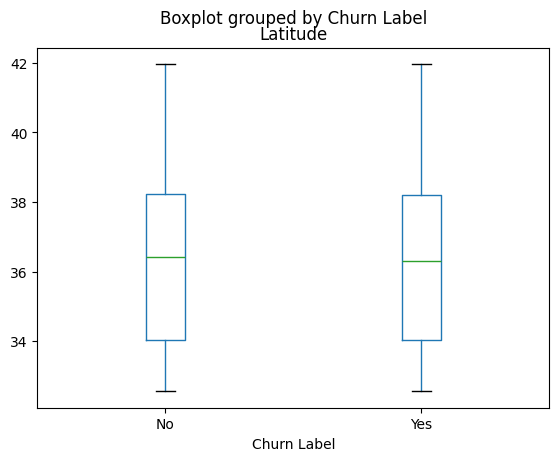

<Figure size 1000x1000 with 0 Axes>

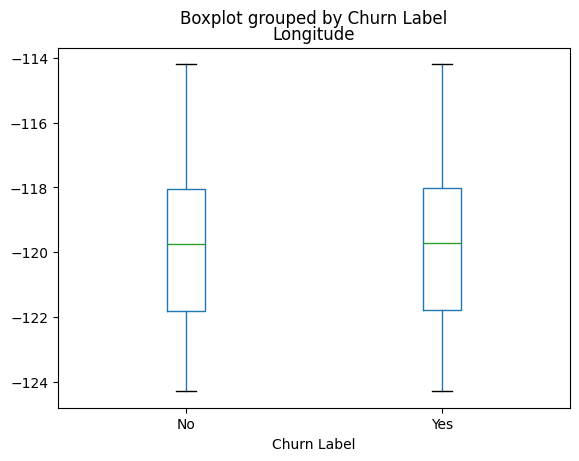

<Figure size 1000x1000 with 0 Axes>

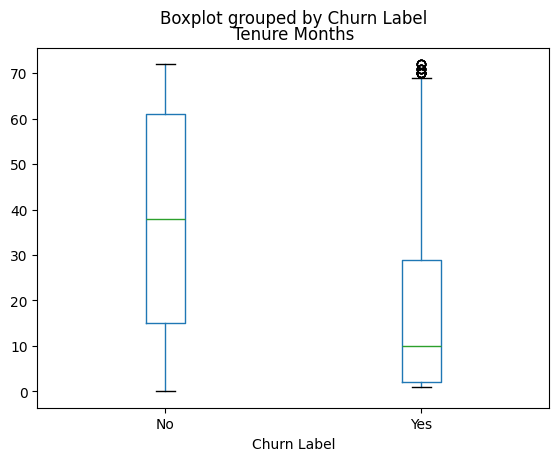

<Figure size 1000x1000 with 0 Axes>

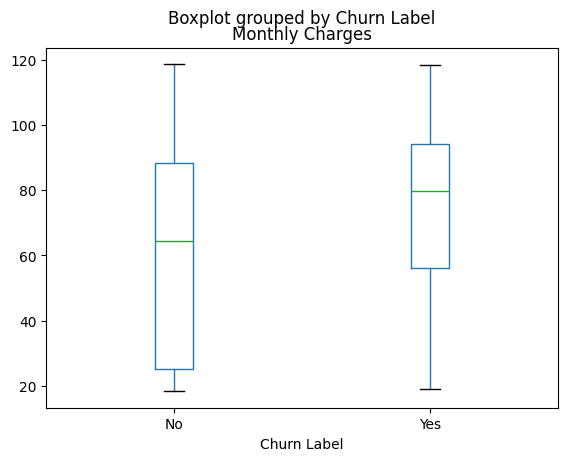

<Figure size 1000x1000 with 0 Axes>

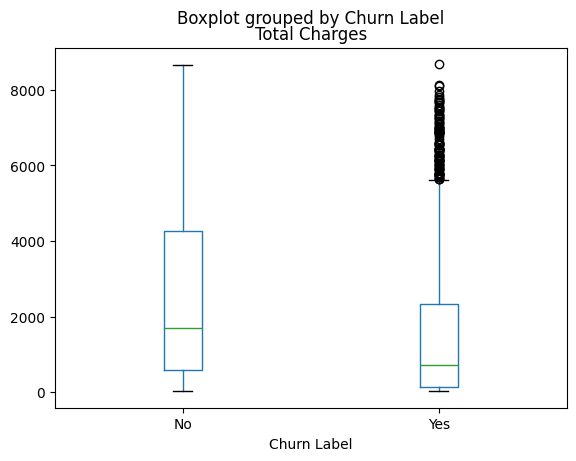

<Figure size 1000x1000 with 0 Axes>

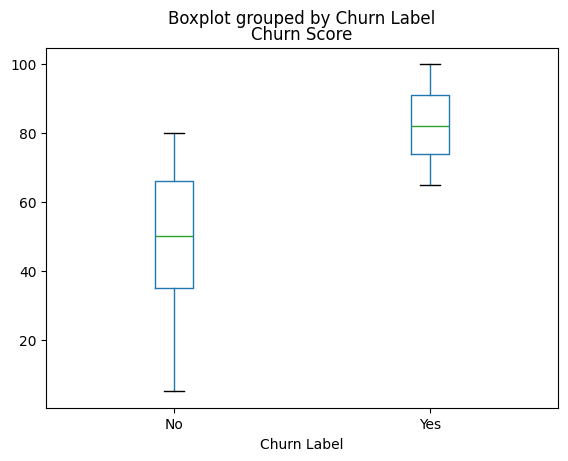

<Figure size 1000x1000 with 0 Axes>

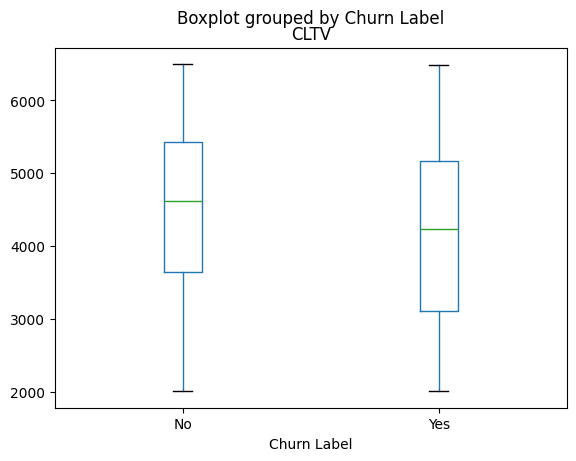

In [ ]:
import matplotlib.pyplot as plt

num_vars = df.select_dtypes(include='number').columns.to_list()

for var in num_vars:
    plt.figure(figsize=(10,10), )
    df.boxplot(var, by='Churn Label', grid=False)
    plt.show()

**Variables numéricas - Candidatas a buenas predictoras**

- Tenure Months puede ser una buena variables predictora porque hay diferencia en los box (No son iguales, no están a la misma altura)
- Monthly charge, hay alguna diferencia (No muy grande)
- Total charges, hay alguna diferencia (no muy grande pero más que monthly charges)
- Churn score, muy buena, hay bastante diferencia (Aunque realmente no es claro si esta variable se produce antes o despues de que el cliente se va)

1. Churn Score
2. Tenure Months
3. Monthly Charges
4. Total Charges

<Figure size 640x480 with 0 Axes>

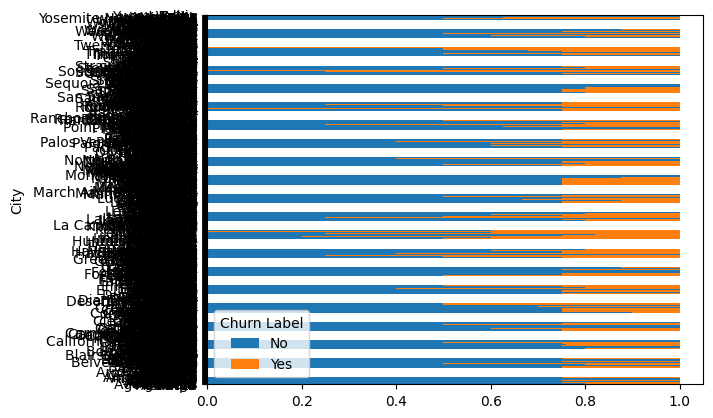

<Figure size 640x480 with 0 Axes>

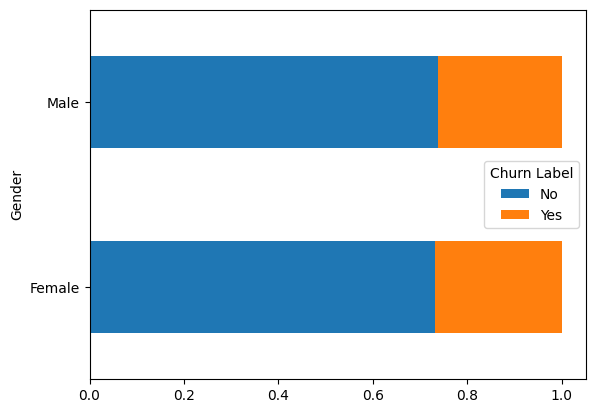

<Figure size 640x480 with 0 Axes>

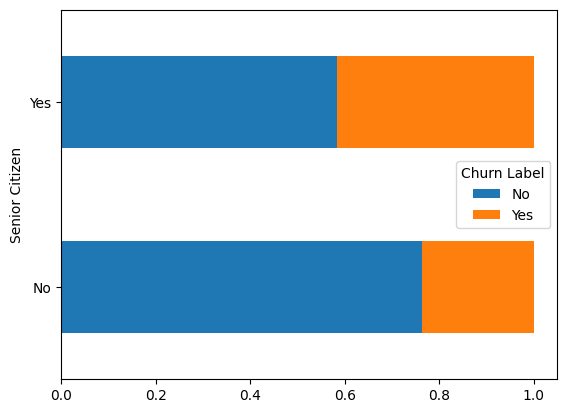

<Figure size 640x480 with 0 Axes>

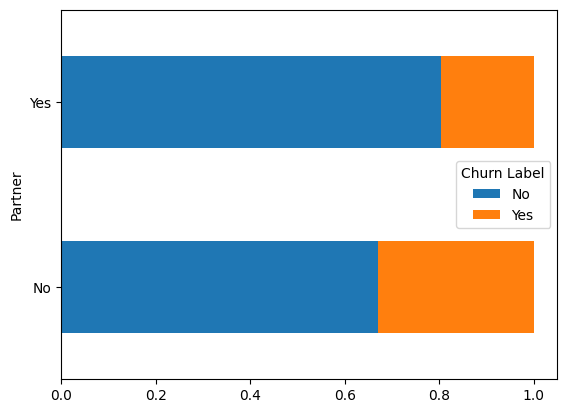

<Figure size 640x480 with 0 Axes>

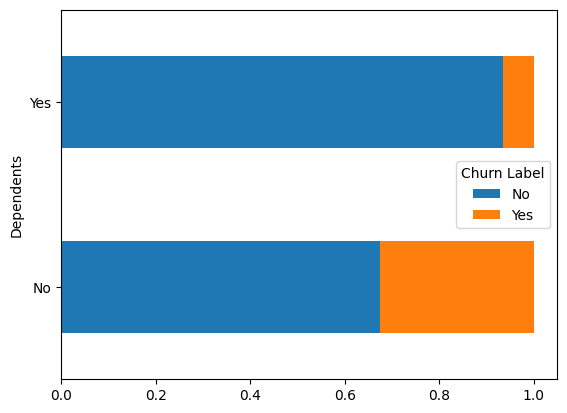

<Figure size 640x480 with 0 Axes>

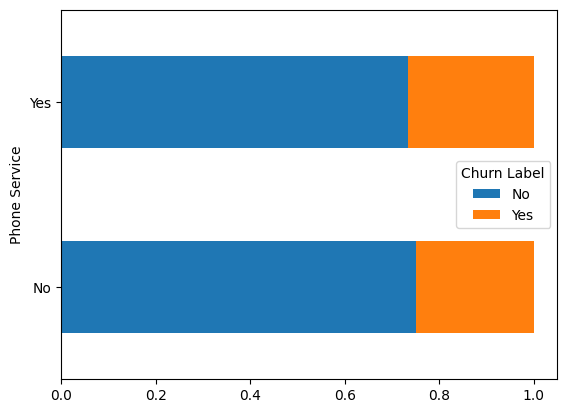

<Figure size 640x480 with 0 Axes>

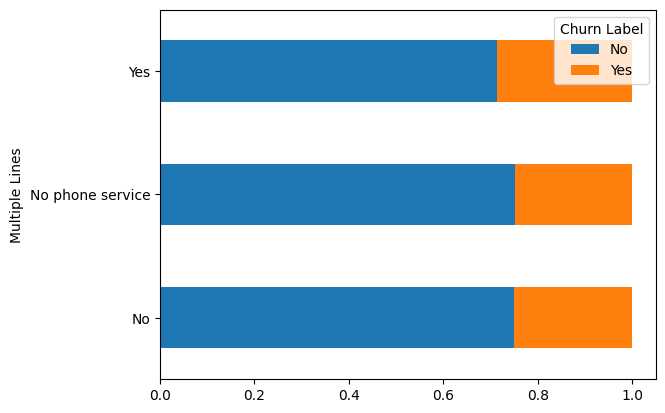

<Figure size 640x480 with 0 Axes>

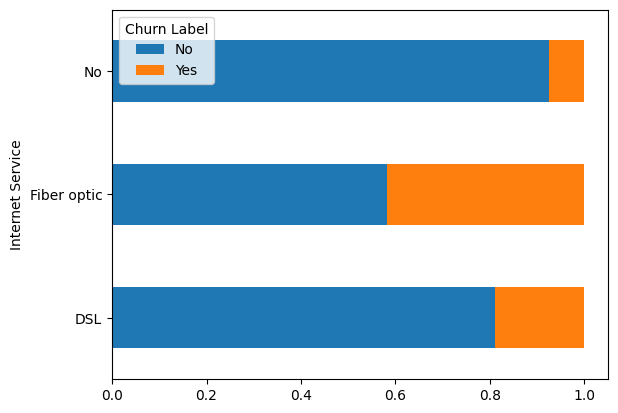

<Figure size 640x480 with 0 Axes>

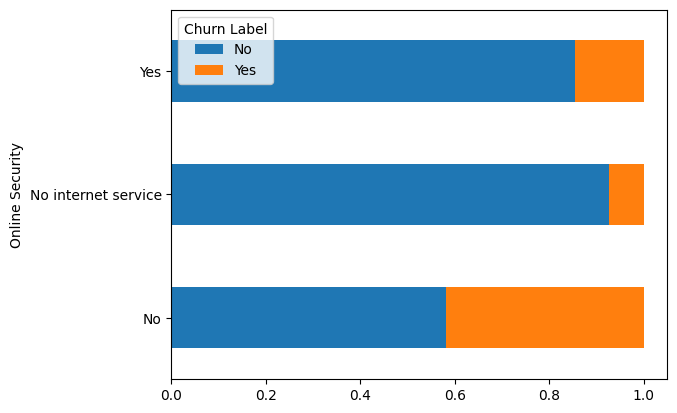

<Figure size 640x480 with 0 Axes>

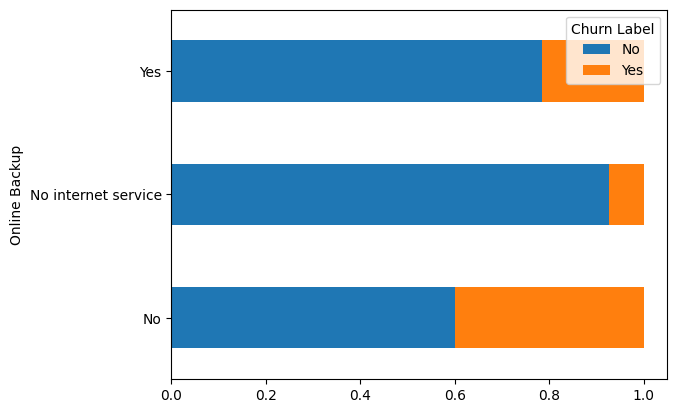

<Figure size 640x480 with 0 Axes>

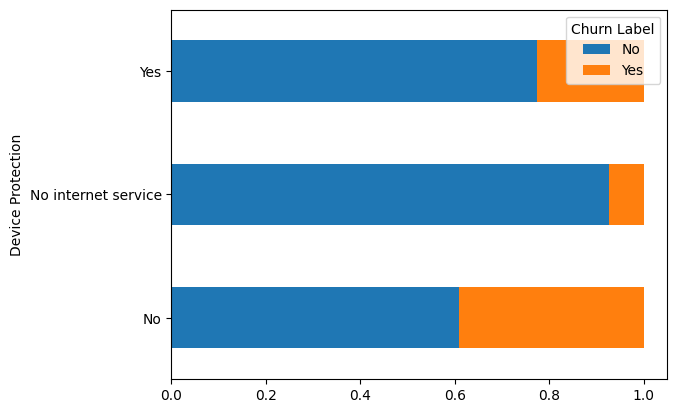

<Figure size 640x480 with 0 Axes>

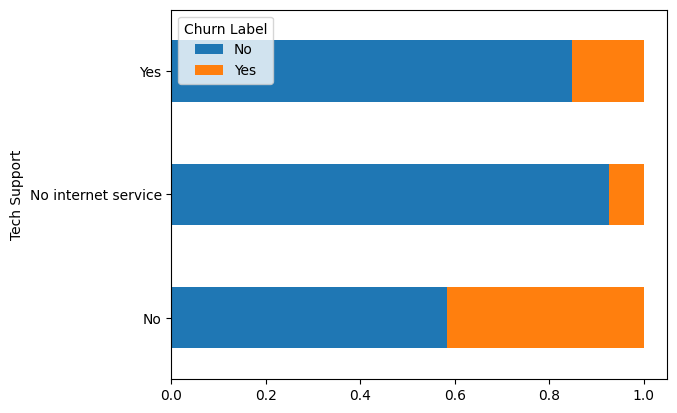

<Figure size 640x480 with 0 Axes>

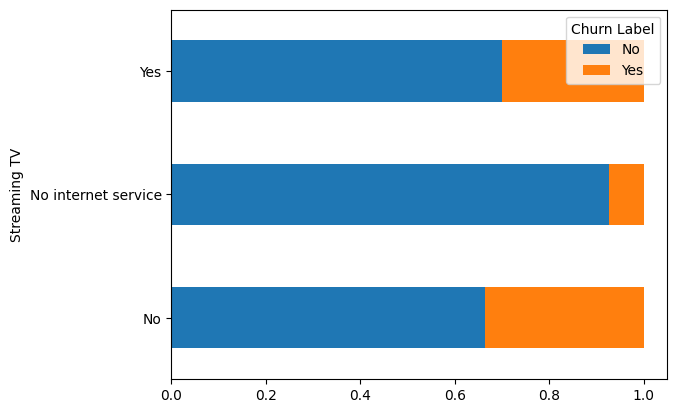

<Figure size 640x480 with 0 Axes>

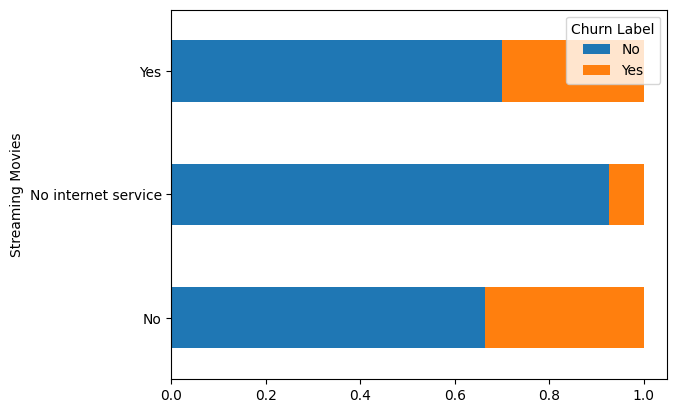

<Figure size 640x480 with 0 Axes>

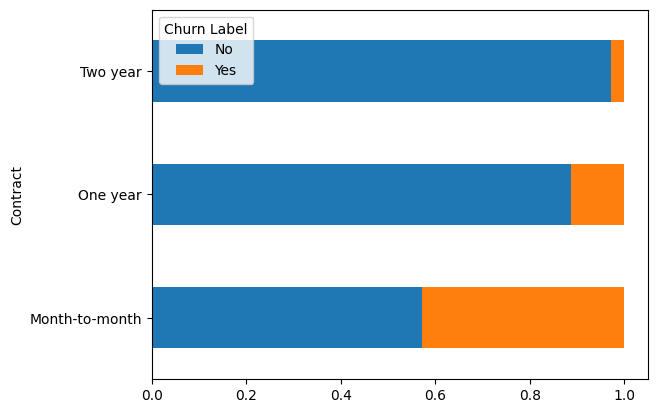

<Figure size 640x480 with 0 Axes>

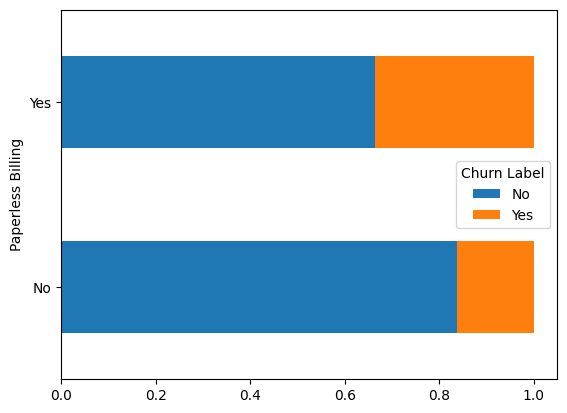

<Figure size 640x480 with 0 Axes>

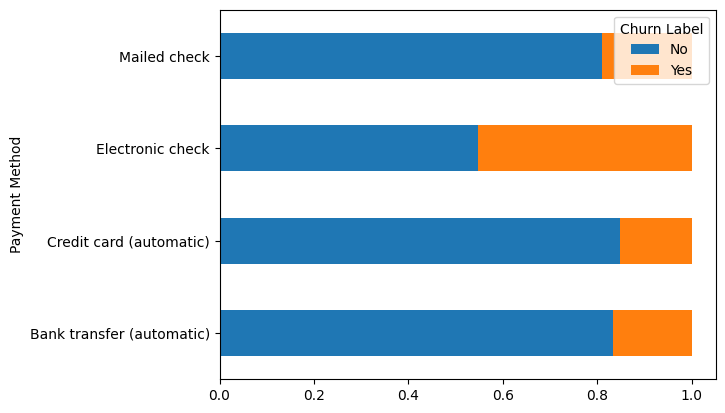

<Figure size 640x480 with 0 Axes>

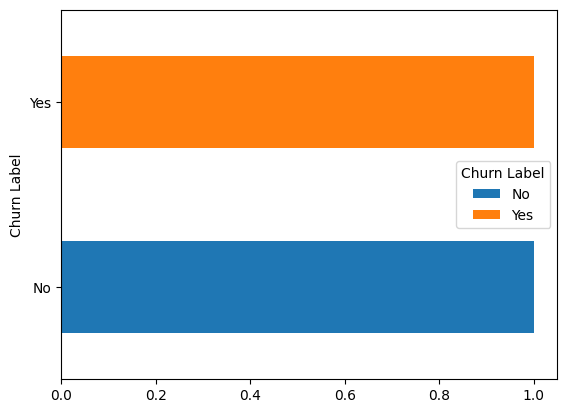

In [43]:
for var in cat_vars:
    tabla = pd.crosstab(df[var], df["Churn Label"], normalize='index')
    plt.figure()
    tabla.plot(kind='barh', stacked=True)
    plt.show()

**Variables categóricas**

- En city no se puede ver nada
- Gender no tiene alguna diferencia si hablamos de Churn Label (Las barras se ven prácticamente iguales)
- Senior Citizen, aquí si hay una diferencia: Las personas que no son senior citizen tienden a retirarse menos (Buena predictora)
- Partner hay cierta diferencia: Las personas que tienen pareja tienden a retirarse menos (Buena predictora)
- Dependents hay cierta diferencia: Si son dependents tienden a retirarse menos (Buena predictora)
- Phone Service no tiene alguna diferencia
- Multiple lines no hay mayor diferencia
- Internet Service hay diferencia (puede ser buena predictora)
- Online security puede servir -> Online security (Elegimos esta porque online security, online backup, device protection y tech support se parecen mucho, entonces elegimos una)
- Online backup, se parece mucho a online security (y tiene sentido)
- Device protection, se parece mucho a online security
- Tech support, también se parece mucho a las anteriores
- Streaming TV hay diferencia (puede ser buena predictora)
- Streaming movies se parece a streaming TV
- Contract si tiene bastante diferencia (Buena predictora)
- Paperless Billing tiene alguna diferencia (puede ser buena predictora)
- Payment method hay alguna diferencia (puede ser buena predictora)


**Candidatas a buenas predictoras**

1. Senior citizen
2. Dependents
3. Internet Service

**Variables para el modelo**

NOTA: Como ninguna variable es normal no usamos StandarScaler

- Churn Score: MinMaxScaler -> Numérica
- Tenure Months: MinMaxScaler -> Numérica
- Contract: OrdinalEncoder -> Ordinal
- Senior Citizen, Dependents, Internet Service: OneHotEncoder -> Nominales

In [44]:
from sklearn.model_selection import train_test_split

#X tiene todas las variables menos la que quiero predecir 'Churn Label'
X = df.drop(
    ['Churn Label'],
    axis=1
    )

#Variable que quiero predecir
y = df['Churn Label']

#Parto el dataframe en datos de entrenamiento y de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (5634, 25)
Tamaño del conjunto de prueba es: (1409, 25)


In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

mm = MinMaxScaler()
orden = ['Month-to-month', 'One year', 'Two year']
ore = OrdinalEncoder(categories=[orden], dtype='int')
ohe = OneHotEncoder(sparse_output=False, drop='if_binary')

preprocessor = ColumnTransformer(transformers=[
    ('score_tenure', mm, ['Churn Score', 'Tenure Months']),
    ('contract', ore, ['Contract']),
    ('citizen_dependents_internet', ohe, ['Senior Citizen', 'Dependents', 'Internet Service'])
    ],
    remainder='drop') # El resto de las características se descartan

preprocessor

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=10000))
    ])

pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('score_tenure', ...), ('contract', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
pipeline.fit(X_train, y_train)

print(f'Exactitud del modelo en el conjunto de entrenamiento: {pipeline.score(X_train, y_train)}')
print(f'Exactitud del modelo en el conjunto de prueba: {pipeline.score(X_test, y_test)}')

Exactitud del modelo en el conjunto de entrenamiento: 0.9208377706780263
Exactitud del modelo en el conjunto de prueba: 0.9141234918381831


In [49]:
#Características
pipeline.named_steps['preprocessor'].get_feature_names_out()

array(['score_tenure__Churn Score', 'score_tenure__Tenure Months',
       'contract__Contract',
       'citizen_dependents_internet__Senior Citizen_Yes',
       'citizen_dependents_internet__Dependents_Yes',
       'citizen_dependents_internet__Internet Service_DSL',
       'citizen_dependents_internet__Internet Service_Fiber optic',
       'citizen_dependents_internet__Internet Service_No'], dtype=object)

Vuelva a entrenar el modelo, pero esta vez añada 3 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

Añadimos:

- Monthly Charges: MinMax
- Streaming TV: OneHot
- Partner: OneHot

In [50]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer

mm = MinMaxScaler()
orden = ['Month-to-month', 'One year', 'Two year']
ore = OrdinalEncoder(categories=[orden], dtype='int')
ohe = OneHotEncoder(sparse_output=False, drop='if_binary')

preprocessor = ColumnTransformer(transformers=[
    ('score_tenure_monthly', mm, ['Churn Score', 'Tenure Months', 'Monthly Charges']),
    ('contract', ore, ['Contract']),
    ('ohe', ohe, ['Senior Citizen', 'Dependents', 'Internet Service', 'Streaming TV', 'Partner'])
    ],
    remainder='drop') # El resto de las características se descartan

preprocessor

,transformers,"[('score_tenure_monthly', ...), ('contract', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [51]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=10000))
    ])

pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('score_tenure_monthly', ...), ('contract', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
pipeline.fit(X_train, y_train)

print(f'Exactitud del modelo en el conjunto de entrenamiento: {pipeline.score(X_train, y_train)}')
print(f'Exactitud del modelo en el conjunto de prueba: {pipeline.score(X_test, y_test)}')

Exactitud del modelo en el conjunto de entrenamiento: 0.9220802271920483
Exactitud del modelo en el conjunto de prueba: 0.914833215046132


In [53]:
#Características
pipeline.named_steps['preprocessor'].get_feature_names_out()

array(['score_tenure_monthly__Churn Score',
       'score_tenure_monthly__Tenure Months',
       'score_tenure_monthly__Monthly Charges', 'contract__Contract',
       'ohe__Senior Citizen_Yes', 'ohe__Dependents_Yes',
       'ohe__Internet Service_DSL', 'ohe__Internet Service_Fiber optic',
       'ohe__Internet Service_No', 'ohe__Streaming TV_No',
       'ohe__Streaming TV_No internet service', 'ohe__Streaming TV_Yes',
       'ohe__Partner_Yes'], dtype=object)